In [2]:
# %% — Imports
%pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# %% — Load Data
df = pd.read_csv("../data/raw/german_credit_data.csv", index_col=0)

print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Note: you may need to restart the kernel to use updated packages.
Shape: (1000, 9)

Column types:
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
dtype: object

First 5 rows:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
Unnamed: 0,,,,,,,,,
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


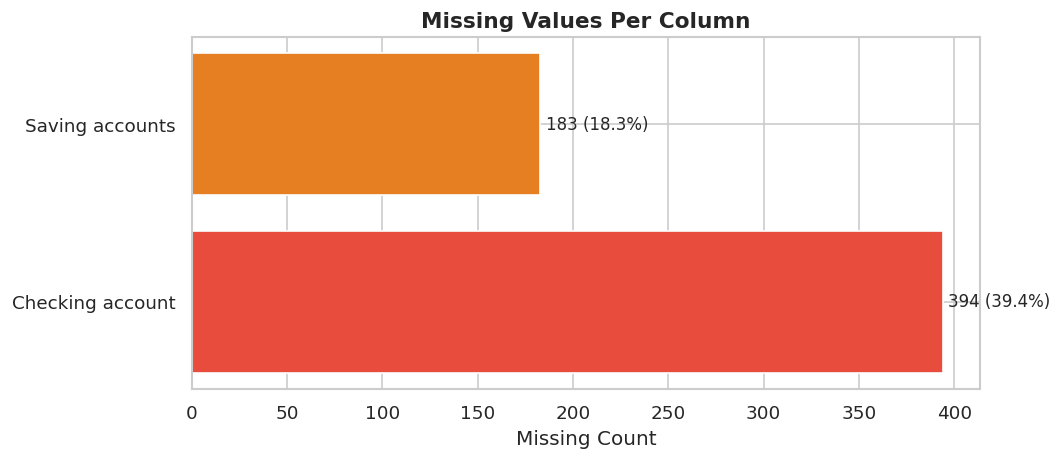

Conclusion: Fill missing with 'none' — absence of account IS information.


In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
bars = ax.barh(missing.index, missing.values, color=["#e74c3c", "#e67e22"])
ax.set_xlabel("Missing Count")
ax.set_title("Missing Values Per Column", fontsize=13, fontweight="bold")
for bar, val in zip(bars, missing.values):
    pct = val / len(df) * 100
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            f"{val} ({pct:.1f}%)", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("../notebooks/missing_values.png")
plt.show()
print("Conclusion: Fill missing with 'none' — absence of account IS information.")

# ## 2. Numeric Feature Distributions

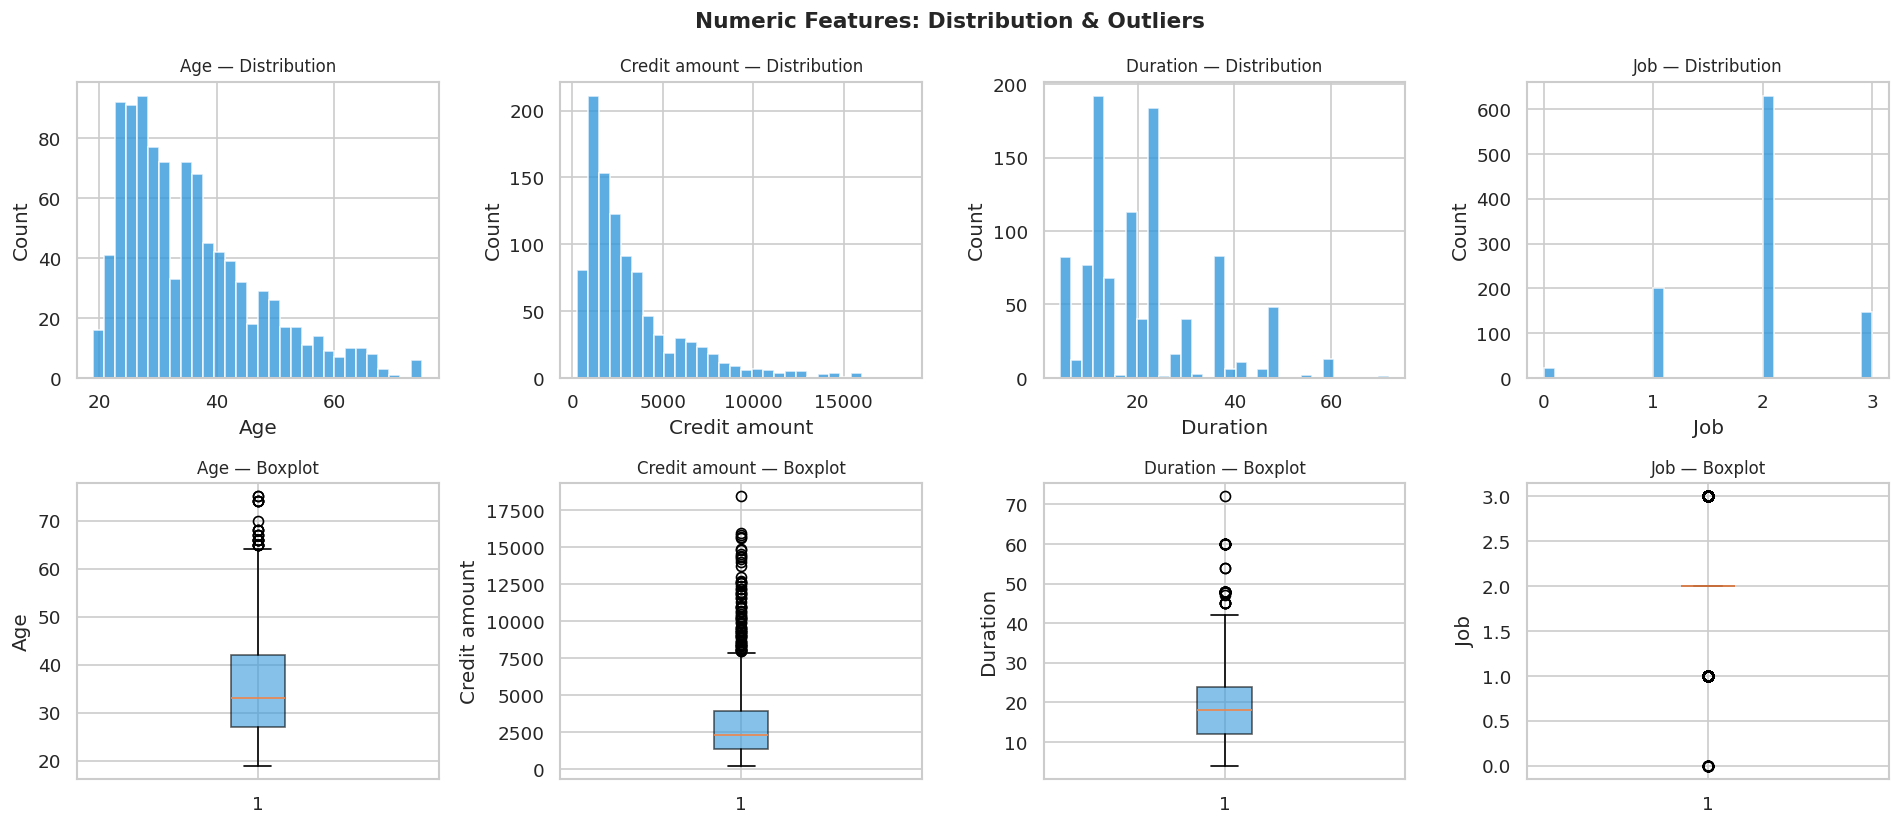


Age:
  min=19, max=75, mean=35.5, std=11.4

Credit amount:
  min=250, max=18424, mean=3271.3, std=2822.7

Duration:
  min=4, max=72, mean=20.9, std=12.1

Job:
  min=0, max=3, mean=1.9, std=0.7


In [5]:
# We look at Age, Credit amount, Duration, and Job.
# Key question: are there outliers that could distort clustering?
numeric_cols = ["Age", "Credit amount", "Duration", "Job"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, col in enumerate(numeric_cols):
    # Histogram
    axes[0, i].hist(df[col], bins=30, color="#3498db", edgecolor="white", alpha=0.8)
    axes[0, i].set_title(f"{col} — Distribution", fontsize=10)
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel("Count")

    # Boxplot
    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor="#3498db", alpha=0.6))
    axes[1, i].set_title(f"{col} — Boxplot", fontsize=10)
    axes[1, i].set_ylabel(col)

plt.suptitle("Numeric Features: Distribution & Outliers", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/numeric_distributions.png")
plt.show()
# Print key stats
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  min={df[col].min()}, max={df[col].max()}, "
          f"mean={df[col].mean():.1f}, std={df[col].std():.1f}")

## 3. Categorical Feature Distribution
We look at Sex, Housing, Saving accounts, Checking account, Purpose.
Key question: are categories balanced or heavily skewed?

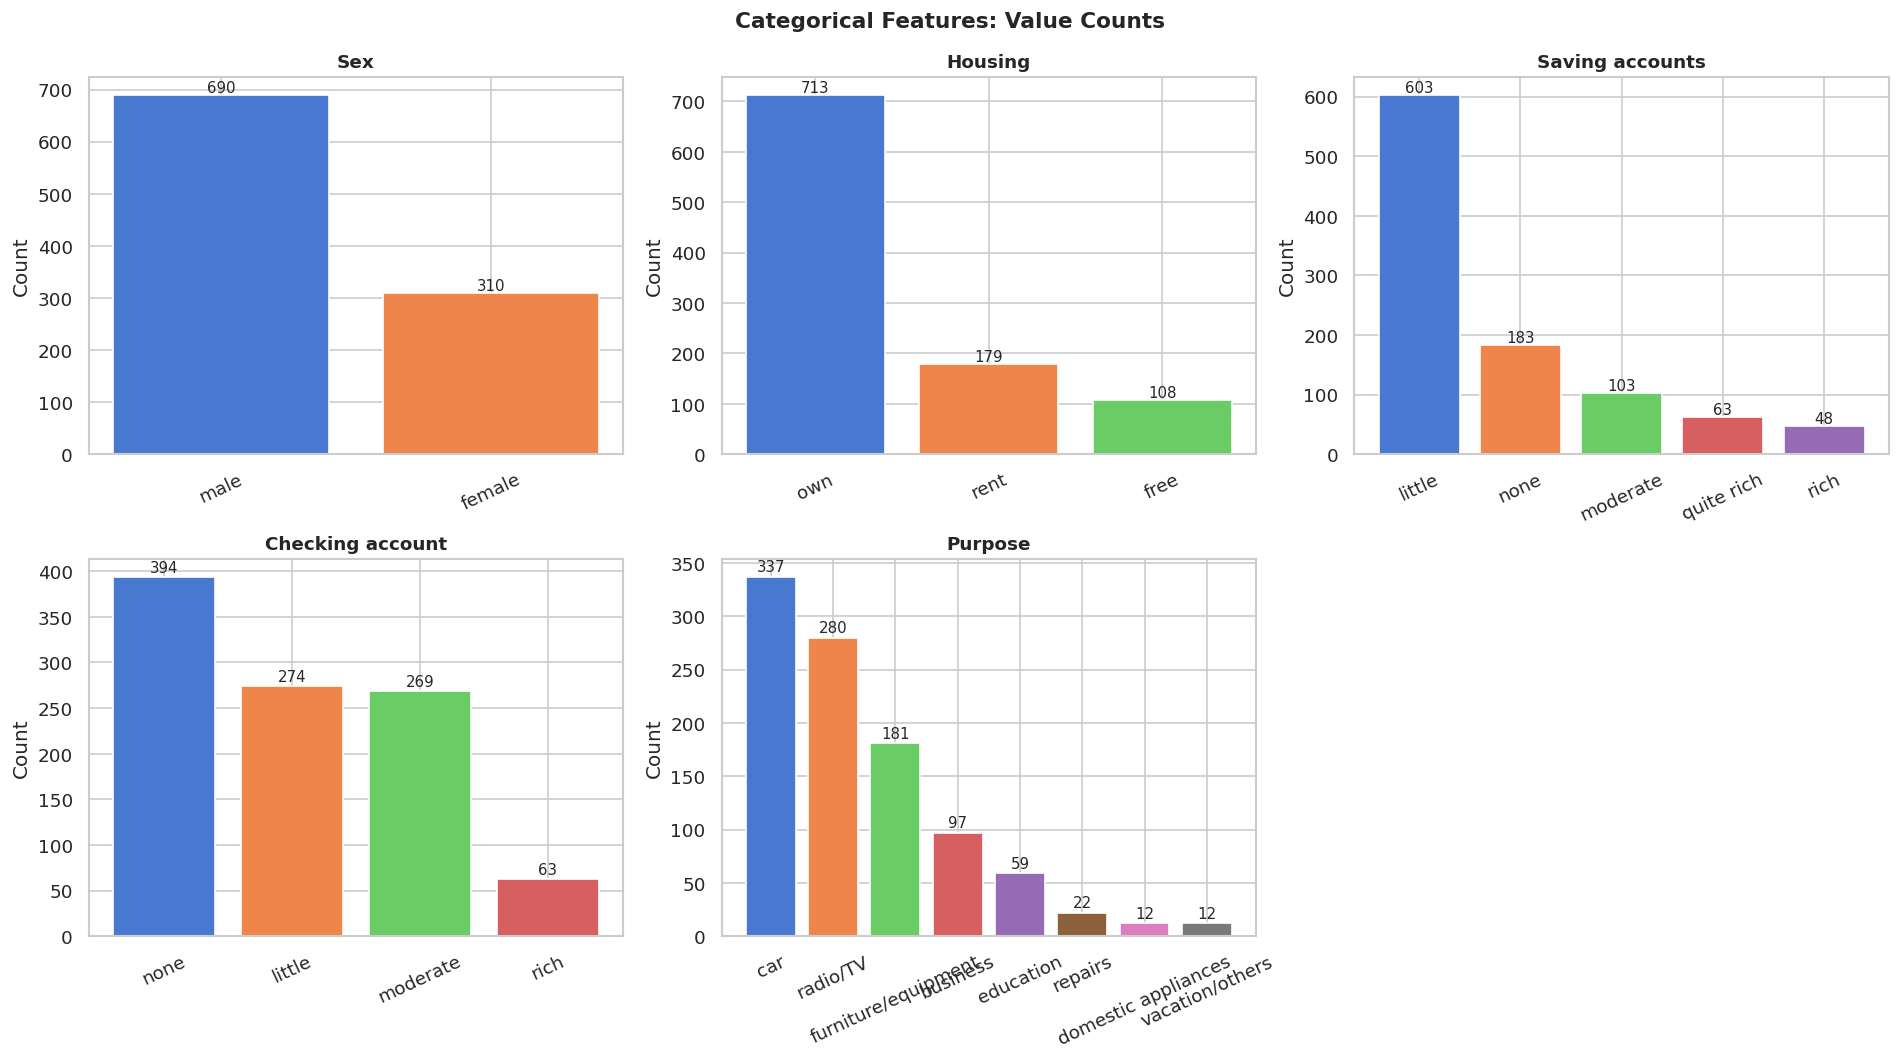

In [6]:
cat_cols = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].fillna("none").value_counts()
    axes[i].bar(counts.index, counts.values,
                color=sns.color_palette("muted", len(counts)))
    axes[i].set_title(f"{col}", fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=25)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha="center", fontsize=9)

axes[-1].set_visible(False)  # hide last empty subplot
plt.suptitle("Categorical Features: Value Counts", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/categorical_distributions.png")
plt.show()

# ## 4. Correlation — Numeric Features


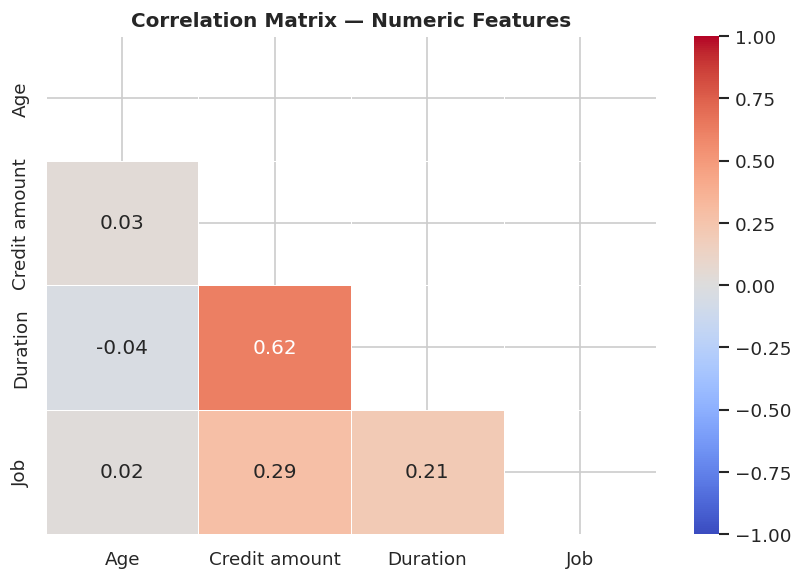

Key insight: Credit amount and Duration tend to correlate.
Longer loans usually = higher amounts.


In [7]:
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix — Numeric Features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/correlation_matrix.png")
plt.show()

print("Key insight: Credit amount and Duration tend to correlate.")
print("Longer loans usually = higher amounts.")

# ## 5. Credit Amount vs Duration — The Core Risk Signal


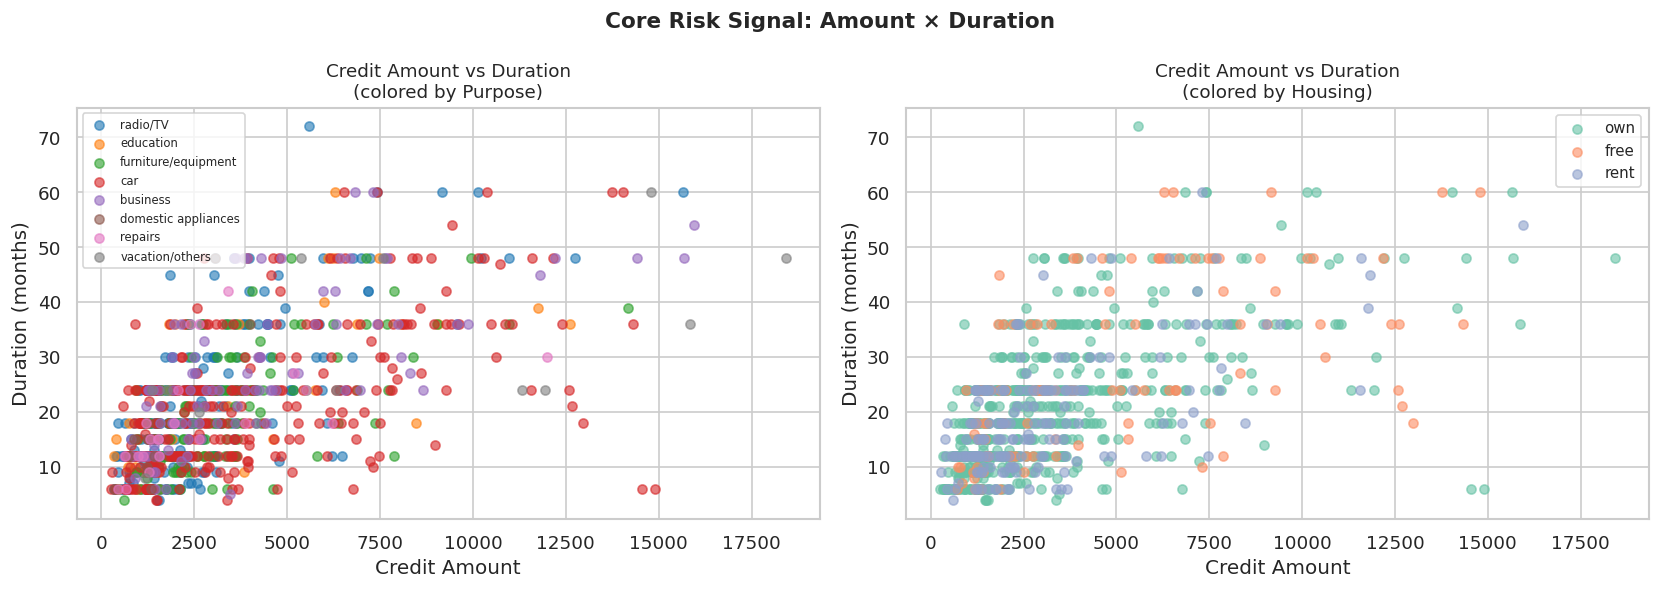

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter colored by Purpose
purposes = df["Purpose"].unique()
colors = sns.color_palette("tab10", len(purposes))
purpose_color = dict(zip(purposes, colors))

for purpose in purposes:
    subset = df[df["Purpose"] == purpose]
    axes[0].scatter(subset["Credit amount"], subset["Duration"],
                    label=purpose, alpha=0.6, s=30,
                    color=purpose_color[purpose])
axes[0].set_xlabel("Credit Amount")
axes[0].set_ylabel("Duration (months)")
axes[0].set_title("Credit Amount vs Duration\n(colored by Purpose)", fontsize=11)
axes[0].legend(fontsize=7, loc="upper left")

# Scatter colored by Housing
housing_types = df["Housing"].unique()
h_colors = sns.color_palette("Set2", len(housing_types))
for j, h in enumerate(housing_types):
    subset = df[df["Housing"] == h]
    axes[1].scatter(subset["Credit amount"], subset["Duration"],
                    label=h, alpha=0.6, s=30, color=h_colors[j])
axes[1].set_xlabel("Credit Amount")
axes[1].set_ylabel("Duration (months)")
axes[1].set_title("Credit Amount vs Duration\n(colored by Housing)", fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle("Core Risk Signal: Amount × Duration", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/amount_vs_duration.png")
plt.show()

# ## 6. Age Distribution by Sex and Housing


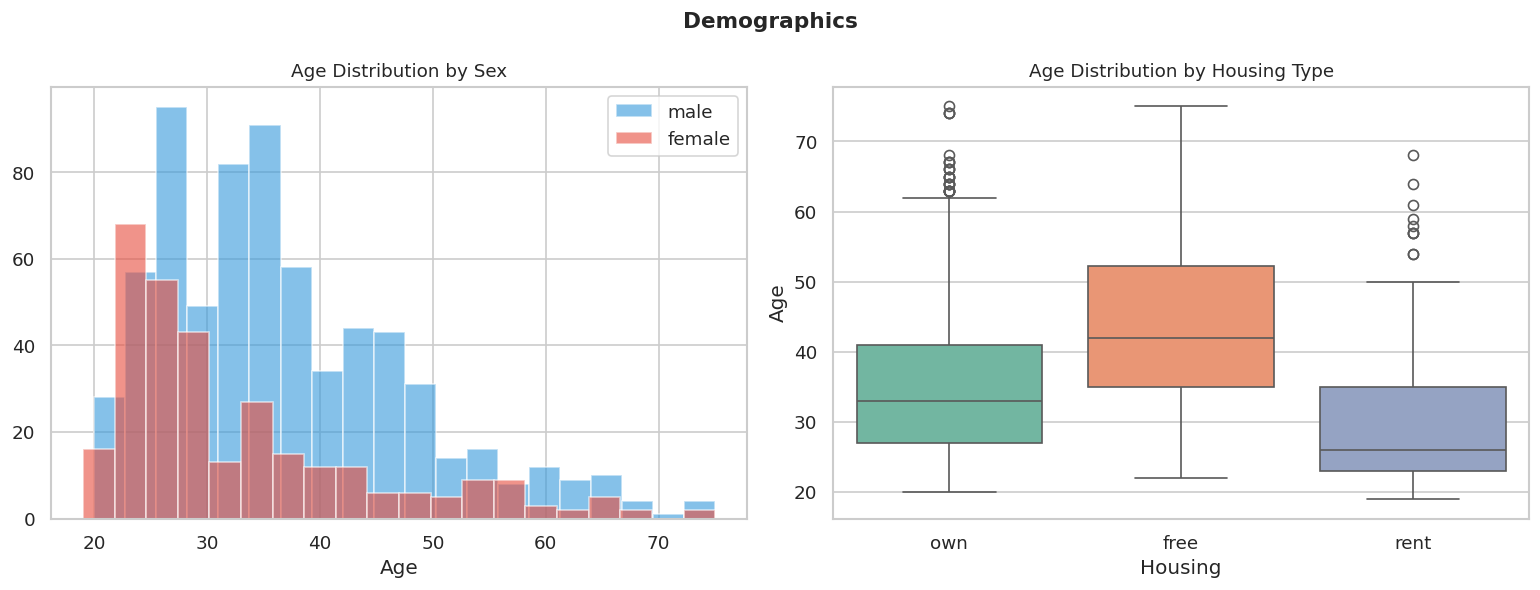

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for sex, color in zip(["male", "female"], ["#3498db", "#e74c3c"]):
    subset = df[df["Sex"] == sex]["Age"]
    axes[0].hist(subset, bins=20, alpha=0.6, label=sex, color=color, edgecolor="white")
axes[0].set_title("Age Distribution by Sex", fontsize=11)
axes[0].set_xlabel("Age")
axes[0].legend()

sns.boxplot(data=df, x="Housing", y="Age",
            palette="Set2", ax=axes[1])
axes[1].set_title("Age Distribution by Housing Type", fontsize=11)
axes[1].set_xlabel("Housing")
axes[1].set_ylabel("Age")

plt.suptitle("Demographics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/demographics.png")
plt.show()

# 7. Savings & Checking Account — The Strongest Risk Signals
These two features (with 18% and 39% missing) are likely the most
important. A customer with no checking account and no savings
requesting a large long-term loan is a very different profile
from one with rich accounts.

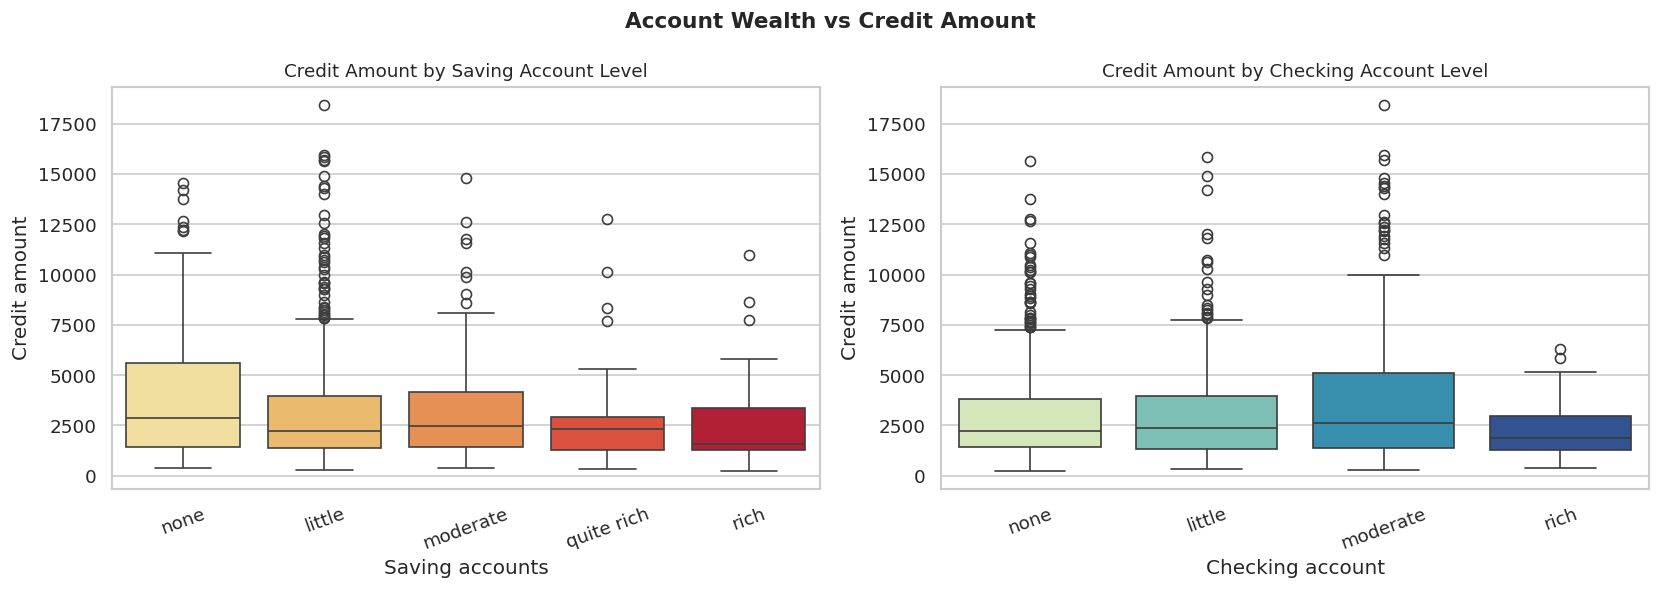

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_saving = ["none", "little", "moderate", "quite rich", "rich"]
order_checking = ["none", "little", "moderate", "rich"]

df_plot = df.copy()
df_plot["Saving accounts"] = df_plot["Saving accounts"].fillna("none")
df_plot["Checking account"] = df_plot["Checking account"].fillna("none")

# Credit amount by savings level
sns.boxplot(data=df_plot, x="Saving accounts", y="Credit amount",
            order=order_saving, palette="YlOrRd", ax=axes[0])
axes[0].set_title("Credit Amount by Saving Account Level", fontsize=11)
axes[0].tick_params(axis="x", rotation=20)

# Credit amount by checking level
sns.boxplot(data=df_plot, x="Checking account", y="Credit amount",
            order=order_checking, palette="YlGnBu", ax=axes[1])
axes[1].set_title("Credit Amount by Checking Account Level", fontsize=11)
axes[1].tick_params(axis="x", rotation=20)

plt.suptitle("Account Wealth vs Credit Amount", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/account_wealth.png")
plt.show()